In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred))
    )


def mase(y_true, y_pred, y_train):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_train = np.array(y_train)

    naive_error = np.mean(np.abs(np.diff(y_train)))
    return np.mean(np.abs(y_true - y_pred)) / (naive_error)

def theil_u(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    denominator = np.sqrt(np.mean(y_true ** 2) + np.mean(y_pred ** 2))
    u = rmse / denominator
    return u

# Loading the data
df = pd.read_excel('output_week.xlsx')

# Counting values and sorting by week
data = df['WEEK'].value_counts().reset_index()
data.columns = ['WEEK', 'DATA']

# Converting week to a date representing the start of the week
data['WEEK_period'] = pd.to_datetime(data['WEEK'] + '-1', format='%G-%V-%u', errors='coerce')
data = data.sort_values('WEEK_period').reset_index(drop=True)

# ------------------------------
# Smoothing (moving average)
# ------------------------------
data['DATA_smooth'] = data['DATA'].rolling(window=5, center=True).mean()
data['DATA_smooth'].fillna(method='bfill', inplace=True)
data['DATA_smooth'].fillna(method='ffill', inplace=True)

# Log transformation of the data
data['y'] = np.log1p(data[['DATA_smooth']])

# ------------------------------
# Prepare X and y
# ------------------------------

y = data['y'].values.astype(np.float32)

# ------------------------------
# Train/test split
# ------------------------------
split = int(len(y) * 0.7)
y_train, y_test = y[:split], y[split:]

/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_9518/647888520.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['DATA_smooth'].fillna(method='bfill', inplace=True)
/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_9518/647888520.py:45: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['DATA_smooth'].fillna(method='bfill', inplace=True)
/var/folders/36/lb3mdhtj2lldbybnz877q_hr0000gn/T/ipykernel_9518/647888520.p

MAE: 0.1583
RMSE: 0.1977
R2: 0.3604
MAPE (normalized): 6.97%
MAPE (real scale): 17.09%
SMAPE: 7.04%
MASE: 2.1372
Theil's U1: 0.06230808272781199


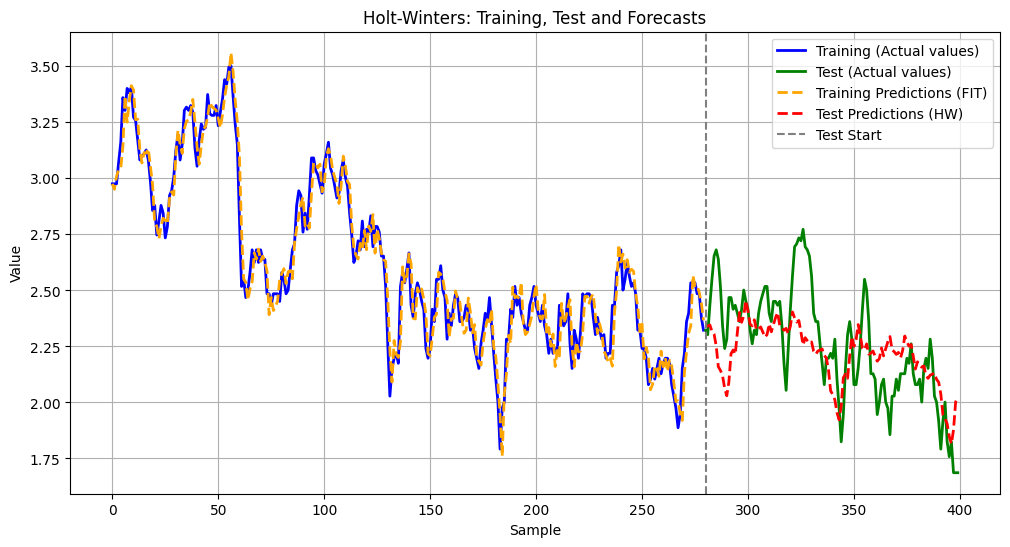

In [ ]:
# 1. Fit Holt-Winters model
model_hw = ExponentialSmoothing(
    y_train,
    trend='add',           # or 'mul'
    seasonal='add',        # or 'mul'
    seasonal_periods=53
).fit(optimized=True)

# 2. Forecast on test set
predictions_hw = model_hw.forecast(len(y_test))

y_pred = predictions_hw

# ------------------------------
# Metrics
# ------------------------------
smape_value = smape(y_test, y_pred)
mase_value = mase(y_test, y_pred, y_train)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Normalized MAPE
mape = np.mean(np.abs((y_test - y_pred) / (y_test))) * 100

# Real-scale MAPE
y_test_real = np.expm1(y_test.reshape(-1, 1)).flatten()
y_pred_real = np.expm1(y_pred.reshape(-1, 1)).flatten()

mape_real = np.mean(np.abs((y_test_real - y_pred_real) / (y_test_real))) * 100

u1 = theil_u(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"MAPE (normalized): {mape:.2f}%")
print(f"MAPE (real scale): {mape_real:.2f}%")
print(f"SMAPE: {smape_value:.2f}%")
print(f"MASE: {mase_value:.4f}")
print("Theil's U1:", u1)

fitted = model_hw.fittedvalues  # in-sample fitted values

plt.figure(figsize=(12, 6))

# indices
idx_train = np.arange(len(y_train))
idx_test = np.arange(len(y_train), len(y_train) + len(y_test))

# ---------------------------
#  ACTUAL VALUES
# ---------------------------

# training actual values
plt.plot(idx_train, y_train,
         label='Training (Actual values)',
         color='blue', linewidth=2)

# test actual values
plt.plot(idx_test, y_test,
         label='Test (Actual values)',
         color='green', linewidth=2)

# ---------------------------
# PREDICTIONS
# ---------------------------

# training fitted values
plt.plot(idx_train, fitted,
         label='Training Predictions (FIT)',
         color='orange', linestyle='--', linewidth=2)

# test predictions
plt.plot(idx_test, y_pred,
         label='Test Predictions (HW)',
         color='red', linestyle='--', linewidth=2)

# ---------------------------
# SPLIT LINE
# ---------------------------

plt.axvline(x=len(y_train), color='gray', linestyle='--', label='Test Start')

plt.title('Holt-Winters: Training, Test and Forecasts')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()